# Week 3 - Day 12
# K-Nearest Neighbors (KNN) Classification using Iris Dataset

## Objective
Learn and implement the KNN algorithm, compare different K values, evaluate performance and save visualizations.

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,ConfusionMatrixDisplay

os.makedirs("../images",exist_ok=True)


## Load Dataset

In [2]:
df=pd.read_csv("../data/iris.csv")
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


## Prepare Features

In [3]:
X=df.drop(columns=["Id","Species"])
y=df["Species"]

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


## Train KNN Models (K=3,5,7)

In [4]:
for k in [3,5,7]:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    pred=model.predict(X_test)
    print(f"K={k} Accuracy:",accuracy_score(y_test,pred))


K=3 Accuracy: 0.9333333333333333
K=5 Accuracy: 0.9333333333333333
K=7 Accuracy: 0.9666666666666667


## Find Best K

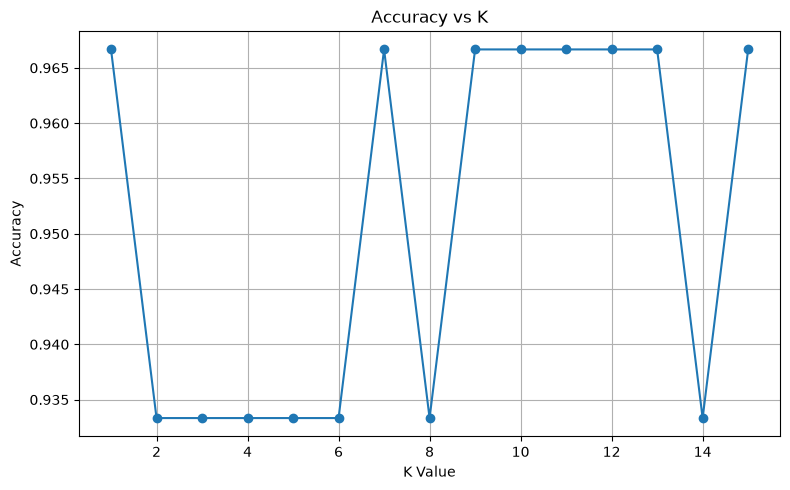

Best K: 1


In [5]:
scores=[]
ks=range(1,16)
for k in ks:
    m=KNeighborsClassifier(n_neighbors=k)
    m.fit(X_train,y_train)
    scores.append(accuracy_score(y_test,m.predict(X_test)))

plt.figure(figsize=(8,5))
plt.plot(list(ks),scores,marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.grid(True)
plt.tight_layout()
plt.savefig("../images/knn_accuracy_vs_k.png",dpi=300)
plt.show()

best_k=list(ks)[scores.index(max(scores))]
print("Best K:",best_k)


## Train Final Model

In [6]:
model=KNeighborsClassifier(n_neighbors=best_k)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))


Accuracy: 0.9666666666666667
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.91      1.00      0.95        10
 Iris-virginica       1.00      0.90      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30



## Confusion Matrix

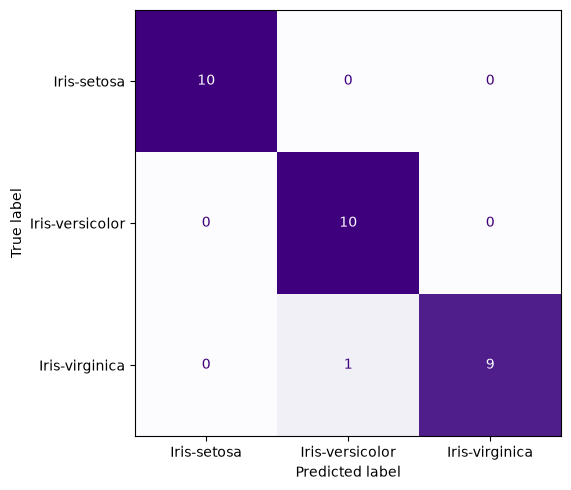

In [7]:
cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(cm,display_labels=model.classes_)
fig,ax=plt.subplots(figsize=(6,5))
disp.plot(ax=ax,cmap="Purples",colorbar=False)
plt.tight_layout()
plt.savefig("../images/confusion_matrix_knn.png",dpi=300)
plt.show()


## Sample Predictions

In [8]:
result=X.iloc[y_test.index if hasattr(y_test,'index') else range(len(y_pred))].copy()
result['Actual']=list(y_test)
result['Predicted']=list(y_pred)
result.head()


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Actual,Predicted
38,4.4,3.0,1.3,0.2,Iris-setosa,Iris-setosa
127,6.1,3.0,4.9,1.8,Iris-virginica,Iris-virginica
57,4.9,2.4,3.3,1.0,Iris-versicolor,Iris-versicolor
93,5.0,2.3,3.3,1.0,Iris-versicolor,Iris-versicolor
42,4.4,3.2,1.3,0.2,Iris-setosa,Iris-setosa


## Conclusion

This notebook demonstrated:
- KNN Classification
- Feature Scaling
- Comparison of K values
- Accuracy vs K graph
- Best K selection
- Classification Report
- Confusion Matrix

Saved Images:
- knn_accuracy_vs_k.png
- confusion_matrix_knn.png
